In [1]:
import sys
sys.path.append("..")  # Adds the parent directory to the path
from utilities.correlations import *
from utilities.explanation import *
from utilities.for_ploting import *
from utilities.imputation import *
from utilities.modelling import *
from utilities.preprocessing import *
from utilities.feature_engineering import *
from utilities.cleaning import *
import pandas as pd

In [2]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [3]:
target = 'Exited'

In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [5]:
test_df[target] = np.array([0] * len(test_df))

In [6]:
all_samples = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [7]:
features = all_samples.columns.tolist()
features = [col for col in features if col not in ['id','CustomerId',target]]

In [8]:
all_samples.columns.tolist()

['id',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [9]:
all_samples = cluster_and_assign_group_prediction(all_samples, train_df.shape[0],features, 10, target)

In [10]:
all_samples.columns.tolist()

['id',
 'CustomerId',
 'Surname',
 'CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'cluster_label',
 'mean_target']

In [11]:
train_x = all_samples.iloc[:train_df.shape[0],:].drop(['id','CustomerId','Exited'],axis=1)
test_x = all_samples.iloc[train_df.shape[0]:,:].drop(['id','CustomerId','Exited'],axis=1)
train_y = all_samples.iloc[:train_df.shape[0],:]['Exited']

In [12]:
cat_cols = train_x.select_dtypes(exclude='number')
for col in cat_cols:
    train_x[col] = train_x[col].astype('category')
    test_x[col] = test_x[col].astype('category')

In [13]:
params = {
    'n_estimators':1000,
    'learning_rate':0.1
}

Class unbalanced: True
[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 31429, number of negative: 117101
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.909890
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.370947
[LightGBM] [Debug] init for col-wise cost 0.001538 seconds, init for row-wise cost 0.008492 seconds
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Debug] Using Sparse Multi-Val Bin
[LightGBM] [Info] Total Bins 2923
[LightGBM] [Info] Number of data points in the train set: 148530, number of used features: 13
[LightGBM] [Info]

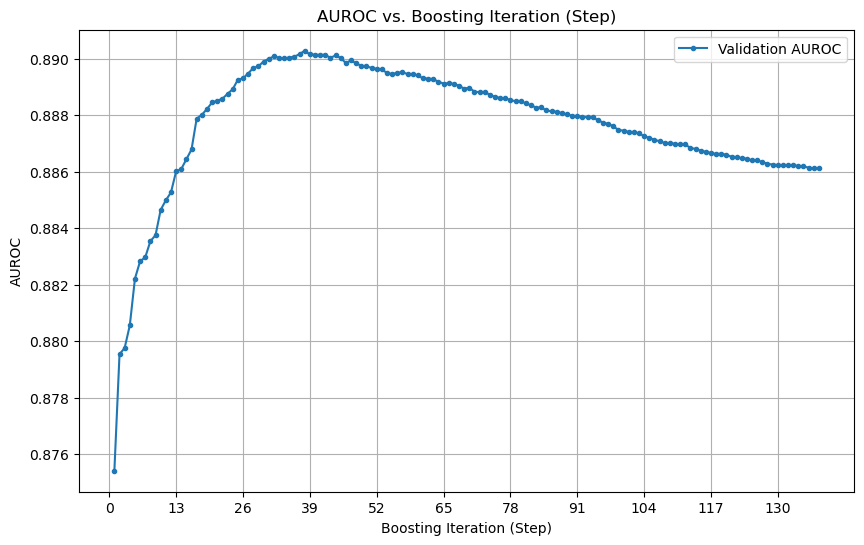


Best Iteration (based on validation AUROC): 38
Best Validation AUROC: 0.8903


In [14]:
model = training_binary_classification_with_lgbm(train_x,train_y,params=params,split=0.1)

C:\Users\qli97\AppData\Roaming\Python\Python312\site-packages\shap\explainers\_tree.py:583: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


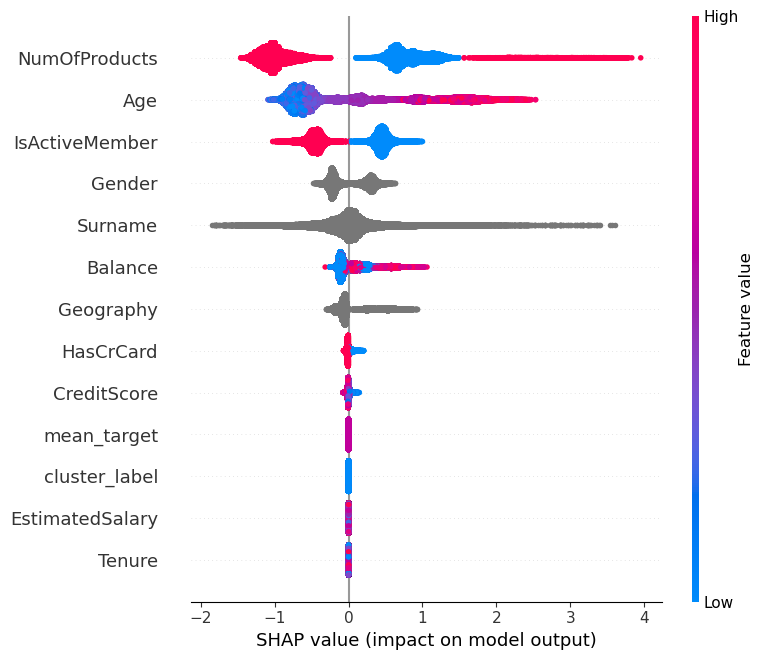

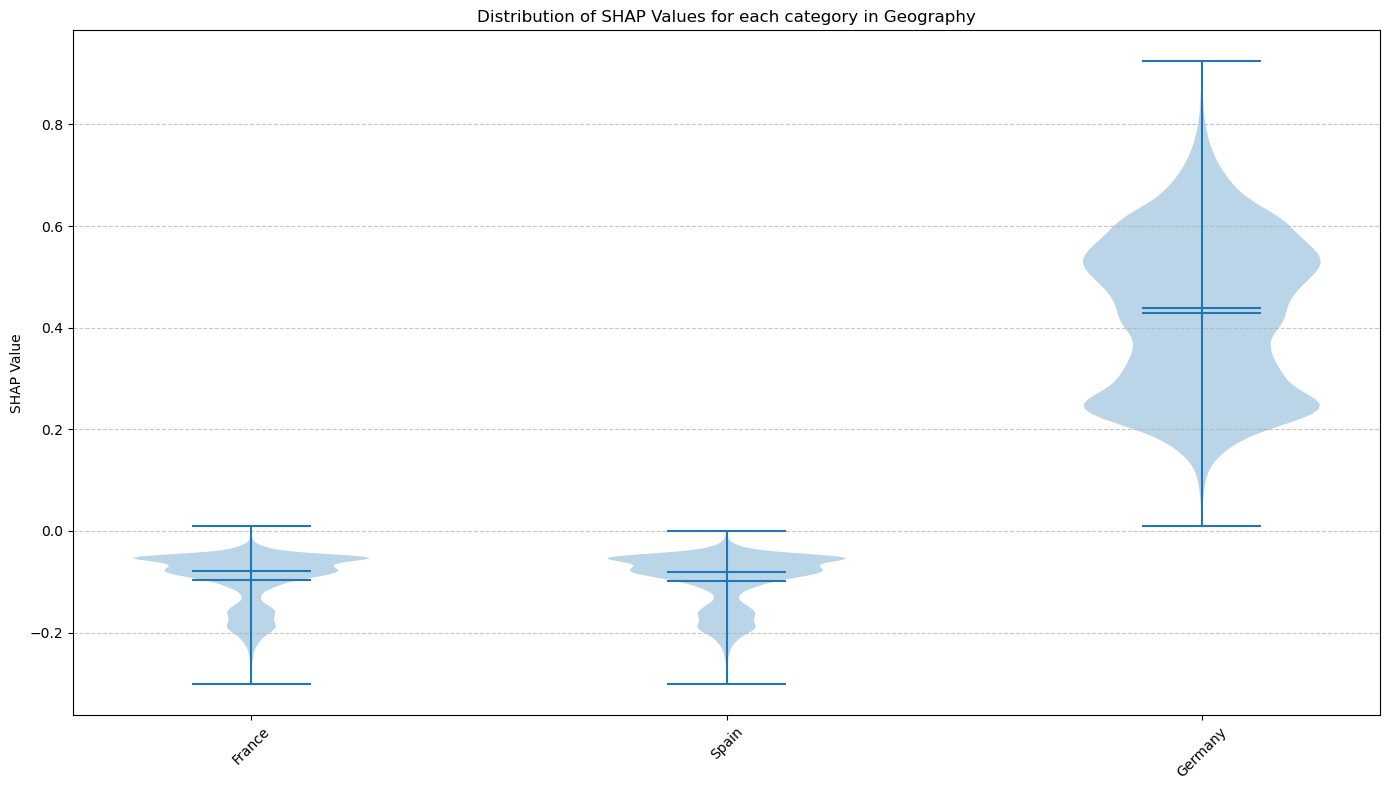

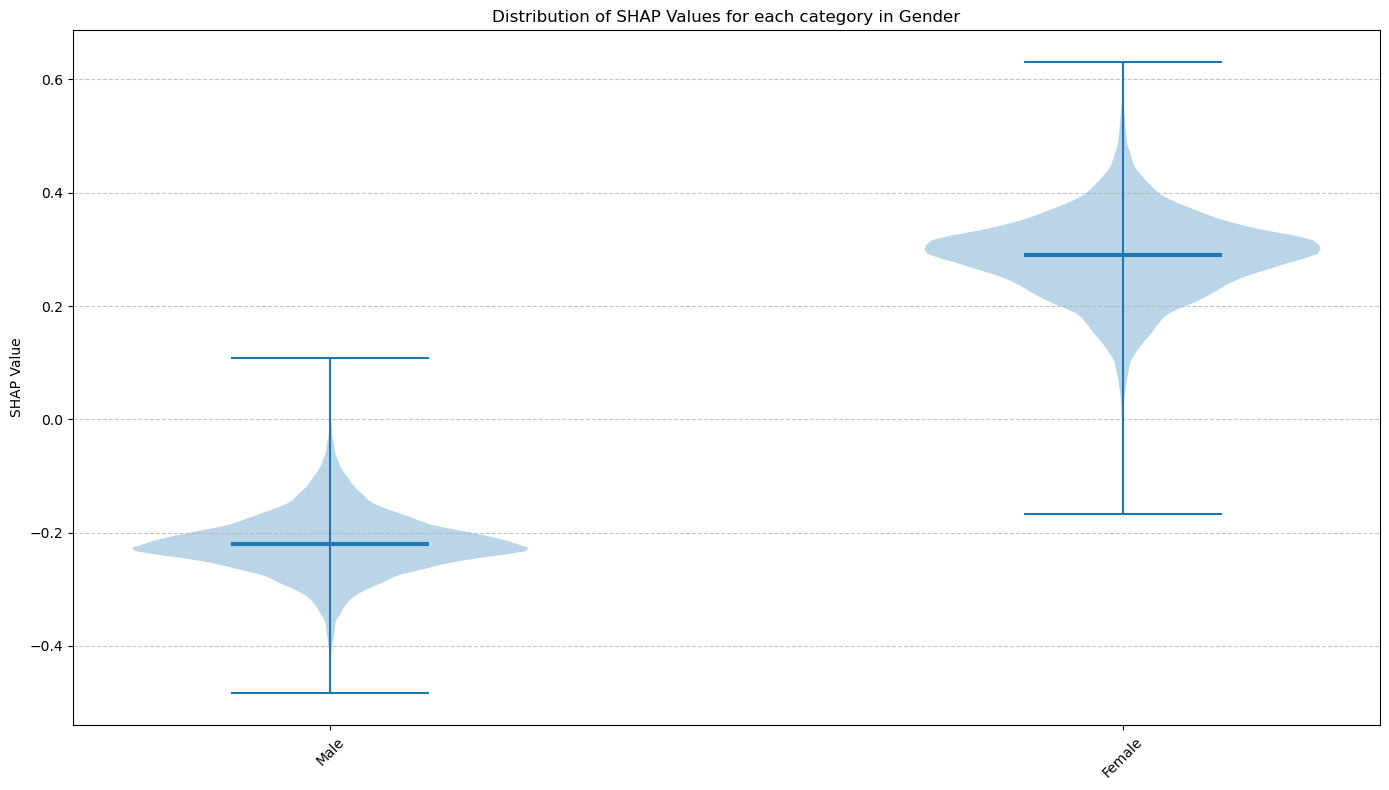

In [15]:
features = all_samples.columns.tolist()
features = [col for col in features if col not in ['id','CustomerId', target]]
excluded_cat_features = ['Surname']
shap_explain_model_on_batch(model, train_x, features,excluded_cat_features)

In [16]:
predictions = model.predict_proba(test_x)[:, 1]
submission_df = pd.DataFrame({"id": test_df["id"], "Exited": predictions})
submission_df.to_csv("submission.csv", index=False)


## Private Score: 0.88863, Public Score: 0.88436